# VC-Genome Pipeline: Scaled Processing (18 Images, 9 VisTypes)

Processes 2 images per VisType (1 low VC + 1 high VC) selected from the 46 pair-comparison images.

**Stage 1:** LLM-assisted extraction — objects, attributes, relationships from `llm_extractions.json`  
**Stage 2:** Canonicalize against ontology  
**Stage 3:** Build scene graphs, compute metrics, render to SVG  

All outputs saved to `vc_genome_output/`.

In [10]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import os, sys, json, graphviz
from pathlib import Path
from collections import defaultdict, Counter
from IPython.display import display, SVG

pd.set_option('display.max_colwidth', 120)

# Graphviz setup for Windows
os.environ['PATH'] = r'C:\Program Files (x86)\Graphviz\bin;' + os.environ.get('PATH', '')
os.environ['PANGOCAIRO_BACKEND'] = 'fontconfig'

# Output directories
OUT_DIR = Path('vc_genome_output')
GRAPH_DIR = OUT_DIR / 'graphs'
OUT_DIR.mkdir(exist_ok=True)
GRAPH_DIR.mkdir(exist_ok=True)
print(f'Output dir: {OUT_DIR.resolve()}')

Output dir: D:\Coding\Copilot\comment_post_processing\vc_genome_output


## Load Data & Select Images

From the 46 pair-comparison images, select 1 low-VC + 1 high-VC per VisType.

In [11]:
compiled = pd.read_csv('phrase_reduction_v2/image_compiled_phrases.csv')
subtopics_df = pd.read_csv('phrase_reduction_v2/phrase_shortlist.csv')
pairs_df = pd.read_csv('GPT_image_pair_comparison/image_pairs_results.csv')

# Get the 46 pair images
pair_imgs = set(pairs_df['image1'].tolist() + pairs_df['image2'].tolist())
pair_compiled = compiled[compiled['imageName'].isin(pair_imgs)].copy()

# Select 1 low + 1 high per VisType
selected = []
for vt, grp in pair_compiled.groupby('VisType'):
    sorted_g = grp.sort_values('NormalizedVC')
    selected.append(sorted_g.iloc[0]['imageName'])   # lowest VC
    if len(grp) >= 2:
        selected.append(sorted_g.iloc[-1]['imageName'])  # highest VC

examples = compiled[compiled['imageName'].isin(selected)].copy()
examples = examples.set_index('imageName').loc[selected].reset_index()

print(f'Selected {len(examples)} images across {examples["VisType"].nunique()} VisTypes:\n')
for vt, grp in examples.groupby('VisType', sort=False):
    for _, r in grp.iterrows():
        print(f'  {r["VisType"]:18s} {r["imageName"]:40s} VC={r["NormalizedVC"]:.2f}')

Selected 18 images across 9 VisTypes:

  Area               visMost97.png                            VC=0.38
  Area               InfoVisJ.2402.12(1).png                  VC=0.88
  Bar                VisC.503.6.png                           VC=0.22
  Bar                VisC.167.11.png                          VC=0.50
  Cont.-ColorPatn    VisJ.1515.12.png                         VC=0.58
  Cont.-ColorPatn    VisJ.1541.1(2).png                       VC=0.77
  Glyph              InfoVisJ.1558.9.png                      VC=0.54
  Glyph              SciVisJ.980.12(2).png                    VC=0.77
  Grid               VASTJ.2908.2.png                         VC=0.52
  Grid               InfoVisJ.1149.6(1).png                   VC=0.95
  Line               whoJ44.png                               VC=0.31
  Line               wsj603.png                               VC=0.57
  Node-link          InfoVisC.133.5(3).png                    VC=0.48
  Node-link          InfoVisC.65.5(2).png          

---
## Stage 1: LLM-Assisted Structured Extraction

Load hand-crafted extractions from `vc_genome_output/llm_extractions.json`.  
Each image was processed individually (simulating Claude API calls) to extract:
- **Objects** — visual elements mentioned in participant comments, assigned to image regions
- **Attributes** — descriptive phrases with sentiment (+/−) and subtopic labels
- **Relationships** — semantically grounded S-V-O triples (e.g., `color --obscures--> information`)

In [12]:
# Load LLM-crafted extractions
with open(OUT_DIR / 'llm_extractions.json', 'r', encoding='utf-8') as f:
    stage1_extractions = json.load(f)

# Verify all selected images have extractions
missing = [img for img in examples['imageName'] if img not in stage1_extractions]
if missing:
    print(f"WARNING: Missing extractions for: {missing}")
else:
    print(f"Loaded extractions for all {len(stage1_extractions)} images")

# Summary
print(f"\n{'Image':<42s} {'VC':>5s} {'Obj':>4s} {'Attr':>5s} {'Rel':>4s}")
print('-' * 65)
for _, row in examples.iterrows():
    img = row['imageName']
    d = stage1_extractions[img]
    print(f"{img:<42s} {row['NormalizedVC']:>5.2f} {len(d['objects']):>4d} {len(d['attributes']):>5d} {len(d['relationships']):>4d}")

# Show sample relationships for first 3 images
print('\n--- Sample Relationships (LLM-crafted) ---')
for img in list(stage1_extractions.keys())[:3]:
    objs = {o['id']: o['name'] for o in stage1_extractions[img]['objects']}
    print(f"\n{img}:")
    for r in stage1_extractions[img]['relationships']:
        subj_name = objs.get(r['subj'], '?')
        obj_name = objs.get(r['obj'], '?')
        print(f"  {subj_name} --{r['pred']}--> {obj_name}  [{r['subtopic']}]")

Loaded extractions for all 18 images

Image                                         VC  Obj  Attr  Rel
-----------------------------------------------------------------
visMost97.png                               0.38    3     4    2
InfoVisJ.2402.12(1).png                     0.88    5     5    3
VisC.503.6.png                              0.22    3     4    2
VisC.167.11.png                             0.50    5     3    3
VisJ.1515.12.png                            0.58    6     8    5
VisJ.1541.1(2).png                          0.77    4     4    3
InfoVisJ.1558.9.png                         0.54    7    10    5
SciVisJ.980.12(2).png                       0.77    4     4    3
VASTJ.2908.2.png                            0.52    4     3    3
InfoVisJ.1149.6(1).png                      0.95    5     7    5
whoJ44.png                                  0.31    3     2    2
wsj603.png                                  0.57    5     5    3
InfoVisC.133.5(3).png                       0.48   

---
## Stage 2: Canonicalization

In [14]:
# Object synonym map
OBJECT_SYNSETS = {
    'bar': 'mark.bar', 'dot': 'mark.point', 'point': 'mark.point',
    'shape': 'mark.shape', 'line': 'mark.line', 'vertical_line': 'mark.line',
    'color_segment': 'mark.color_segment', 'color': 'property.color',
    'box': 'structure.panel', 'layout': 'structure.layout',
    'pattern': 'structure.pattern', 'data_pattern': 'structure.pattern',
    'connection': 'structure.link', 'node': 'mark.node', 'link': 'structure.link',
    'title': 'text.title', 'description': 'text.description',
    'axis_label': 'text.axis_label', 'label': 'text.label', 'text': 'text.label',
    'legend': 'furniture.legend', 'color_code': 'furniture.legend',
    'visualization': 'whole.visualization', 'chart': 'whole.visualization',
    'graph': 'whole.visualization', 'image': 'whole.visualization',
    'data': 'content.data', 'information': 'content.data',
    'knowledge': 'content.domain', 'concept': 'content.domain',
    'element': 'mark.element', 'object': 'mark.element',
    'detail': 'content.detail', 'number': 'content.number',
    'area': 'mark.area', 'region': 'structure.region',
    'grid': 'structure.grid', 'cell': 'structure.cell',
    'symbol': 'mark.symbol', 'icon': 'mark.symbol',
    'annotation': 'text.annotation', 'map': 'whole.visualization',
}

# Predicate normalization
PREDICATE_CANON = {
    'describes': 'describes', 'labels': 'describes', 'clarifies': 'clarifies',
    'encodes_via': 'encodes_via', 'fills': 'fills',
    'overlaps_with': 'overlaps_with', 'varies_across': 'varies_across',
    'connects': 'connects', 'fails_to_explain': 'fails_to_explain',
    'obscures': 'obscures', 'scattered_across': 'distributed_across',
    'mixed_with': 'co_occurs_with', 'lacks_story': 'lacks_meaning_for',
    'requires_expertise': 'requires_expertise_for', 'overwhelms': 'overwhelms',
    'distinguish': 'distinguishes', 'understand': 'interpreted_via',
    'interpret': 'interpreted_via', 'read': 'interpreted_via',
    'compare': 'compared_with', 'identify': 'identifies',
    'represent': 'represents', 'show': 'represents',
    'display': 'represents', 'indicate': 'indicates',
    'overlap': 'overlaps_with', 'clutter': 'clutters',
    'confuse': 'confuses', 'simplify': 'simplifies',
}


def canonicalize(extraction):
    """Apply canonicalization to a Stage 1 extraction."""
    canon = {'objects': [], 'attributes': [], 'relationships': []}
    id_map = {}
    for obj in extraction['objects']:
        synset = OBJECT_SYNSETS.get(obj['name'], f"unknown.{obj['name']}")
        id_map[obj['id']] = synset
        canon['objects'].append({
            'id': obj['id'], 'name': obj['name'],
            'synset': synset, 'region': obj['region']
        })
    for attr in extraction['attributes']:
        canon['attributes'].append({
            'object_id': attr['object_id'],
            'object_synset': id_map[attr['object_id']],
            'attr': attr['attr'],
            'sentiment': attr['sentiment'],
            'subtopic': attr['subtopic'],
        })
    for rel in extraction['relationships']:
        canon['relationships'].append({
            'subject_synset': id_map[rel['subj']],
            'predicate': PREDICATE_CANON.get(rel['pred'], rel['pred']),
            'object_synset': id_map[rel['obj']],
            'sentiment': rel['sentiment'],
            'subtopic': rel['subtopic'],
        })
    return canon


stage2_canonical = {}
for img, extraction in stage1_extractions.items():
    stage2_canonical[img] = canonicalize(extraction)

print(f'Canonicalized {len(stage2_canonical)} images')
# Show one example
ex_img = list(stage2_canonical.keys())[0]
print(f'\nExample: {ex_img}')
for o in stage2_canonical[ex_img]['objects']:
    print(f"  {o['name']:20s} -> {o['synset']}")

Canonicalized 18 images

Example: visMost97.png
  color                -> property.color
  information          -> content.data
  knowledge            -> content.domain


---
## Stage 3: Graph Assembly & Metrics

In [15]:
SUBTOPIC_TO_TOPIC = dict(zip(subtopics_df['SubTopic'], subtopics_df['Topic']))


def build_scene_graph(canon_data, image_name):
    G = nx.DiGraph()
    G.graph['image'] = image_name
    for obj in canon_data['objects']:
        G.add_node(obj['synset'], label=obj['name'], synset=obj['synset'],
                   region=obj['region'], node_type='object',
                   attributes=[], sentiments=[])
    for attr in canon_data['attributes']:
        nid = attr['object_synset']
        if nid in G:
            G.nodes[nid]['attributes'].append(attr['attr'])
            G.nodes[nid]['sentiments'].append(attr['sentiment'])
    for rel in canon_data['relationships']:
        G.add_edge(rel['subject_synset'], rel['object_synset'],
                   predicate=rel['predicate'], sentiment=rel['sentiment'],
                   subtopic=rel['subtopic'],
                   topic=SUBTOPIC_TO_TOPIC.get(rel['subtopic'], 'Unknown'))
    return G


def compute_graph_metrics(G):
    n_nodes = G.number_of_nodes()
    n_edges = G.number_of_edges()
    all_sents = [s for n in G.nodes for s in G.nodes[n].get('sentiments', [])]
    all_sents += [G.edges[e]['sentiment'] for e in G.edges]
    n_attrs = sum(len(G.nodes[n].get('attributes', [])) for n in G.nodes)
    n_pos = sum(1 for s in all_sents if s == '+')
    n_neg = sum(1 for s in all_sents if s == '-')
    subtopics_hit = set(G.edges[e].get('subtopic', '') for e in G.edges)
    regions = set(G.nodes[n].get('region', '') for n in G.nodes)
    max_edges = n_nodes * (n_nodes - 1) if n_nodes > 1 else 1
    return {
        'nodes': n_nodes, 'edges': n_edges, 'attributes': n_attrs,
        'attr_density': round(n_attrs / max(n_nodes, 1), 2),
        'edge_density': round(n_edges / max_edges, 3),
        'positive_count': n_pos, 'negative_count': n_neg,
        'positive_ratio': round(n_pos / max(len(all_sents), 1), 2),
        'subtopics_covered': len(subtopics_hit),
        'regions_used': len(regions),
    }


# Build all graphs and compute metrics
scene_graphs = {}
metrics_rows = []
for _, row in examples.iterrows():
    img = row['imageName']
    G = build_scene_graph(stage2_canonical[img], img)
    scene_graphs[img] = G
    m = compute_graph_metrics(G)
    metrics_rows.append({'imageName': img, 'VisType': row['VisType'],
                         'NormalizedVC': row['NormalizedVC'], **m})

metrics_df = pd.DataFrame(metrics_rows)
metrics_df.to_csv(OUT_DIR / 'graph_metrics.csv', index=False)
print(f'Saved metrics for {len(metrics_df)} images to vc_genome_output/graph_metrics.csv\n')
display(metrics_df.style.format({
    'NormalizedVC': '{:.2f}', 'attr_density': '{:.2f}',
    'edge_density': '{:.3f}', 'positive_ratio': '{:.0%}',
}).background_gradient(subset=['NormalizedVC', 'positive_ratio', 'subtopics_covered'], cmap='YlOrRd'))

Saved metrics for 18 images to vc_genome_output/graph_metrics.csv



,imageName,VisType,NormalizedVC,nodes,edges,attributes,attr_density,edge_density,positive_count,negative_count,positive_ratio,subtopics_covered,regions_used
0,visMost97.png,Area,0.38,3,2,4,1.33,0.333,0,6,0%,2,2
1,InfoVisJ.2402.12(1).png,Area,0.88,5,3,5,1.00,0.150,6,2,75%,3,1
2,VisC.503.6.png,Bar,0.22,3,2,4,1.33,0.333,2,4,33%,2,2
3,VisC.167.11.png,Bar,0.50,5,3,3,0.60,0.150,0,6,0%,3,2
4,VisJ.1515.12.png,Cont.-ColorPatn,0.58,6,5,8,1.33,0.167,13,0,100%,5,3
5,VisJ.1541.1(2).png,Cont.-ColorPatn,0.77,4,3,4,1.00,0.250,6,1,86%,3,2
6,InfoVisJ.1558.9.png,Glyph,0.54,7,5,10,1.43,0.119,14,1,93%,4,2
7,SciVisJ.980.12(2).png,Glyph,0.77,4,3,4,1.00,0.250,4,3,57%,3,3
8,VASTJ.2908.2.png,Grid,0.52,4,3,3,0.75,0.250,6,0,100%,3,1
9,InfoVisJ.1149.6(1).png,Grid,0.95,4,5,7,1.75,0.417,12,0,100%,5,3


### Render Scene Graphs to SVG

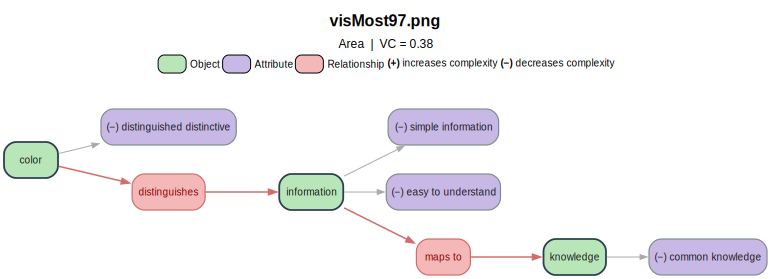

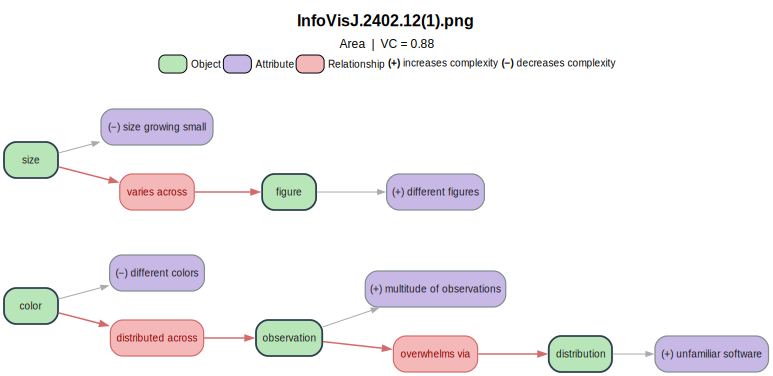

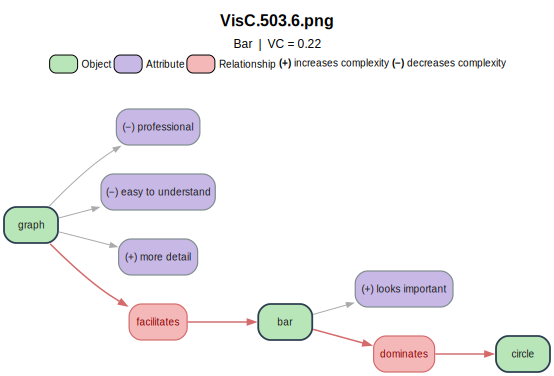

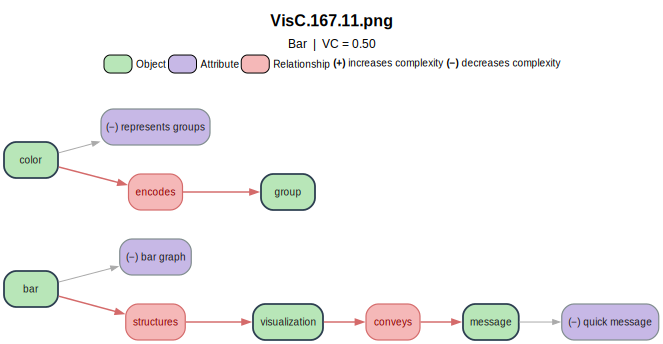

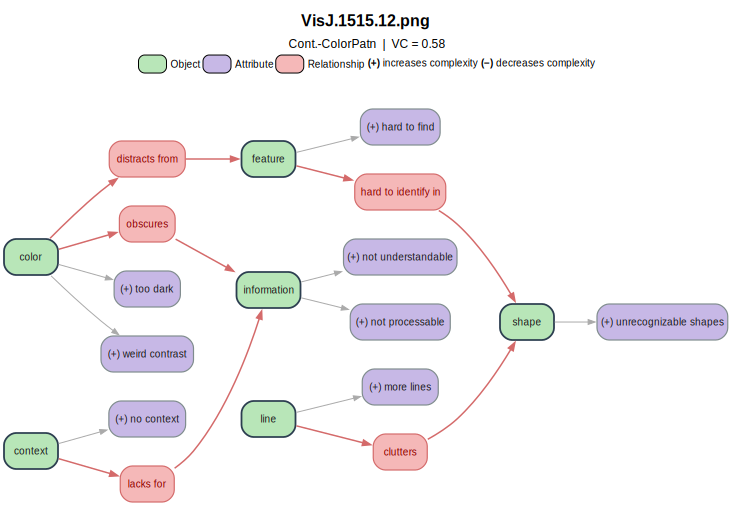

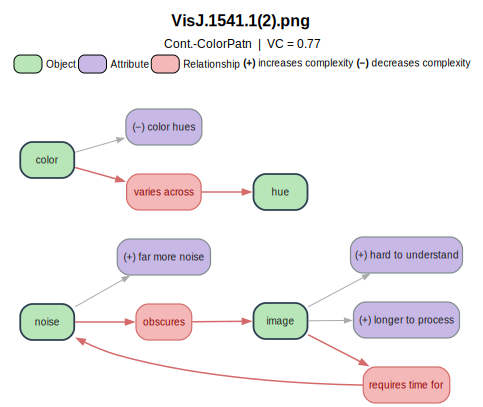

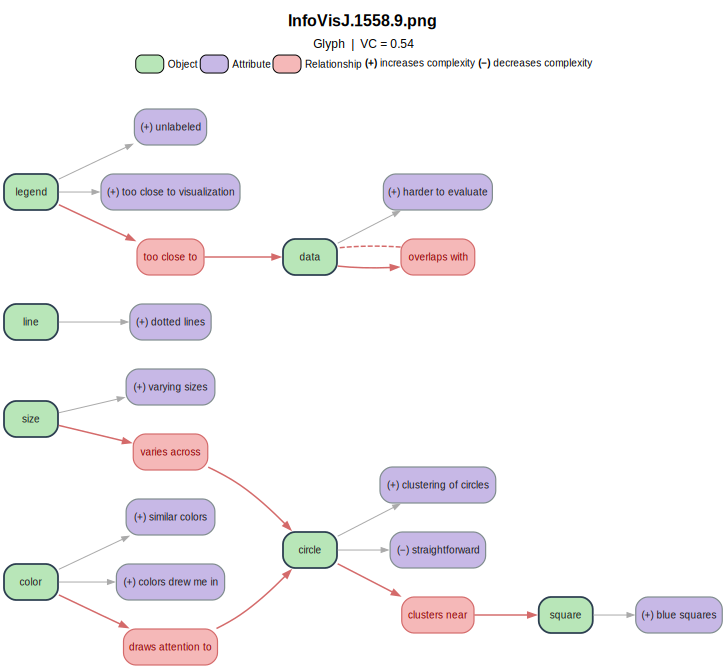

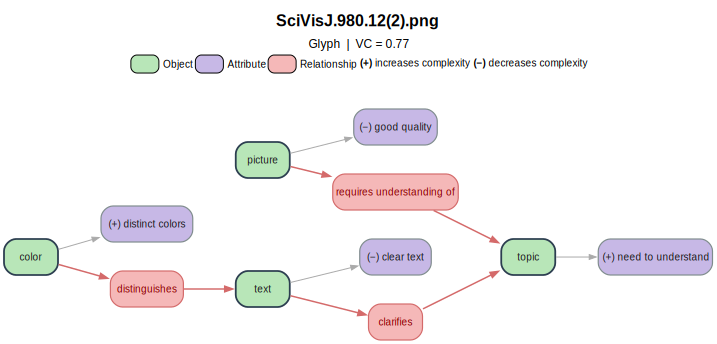

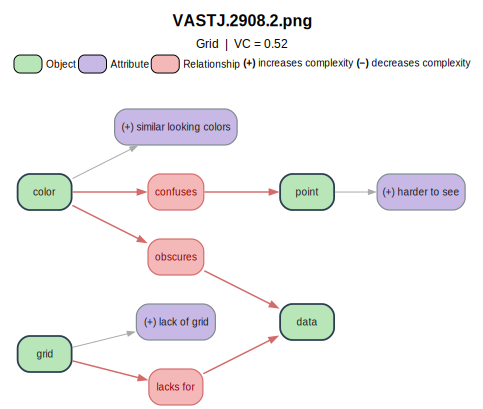

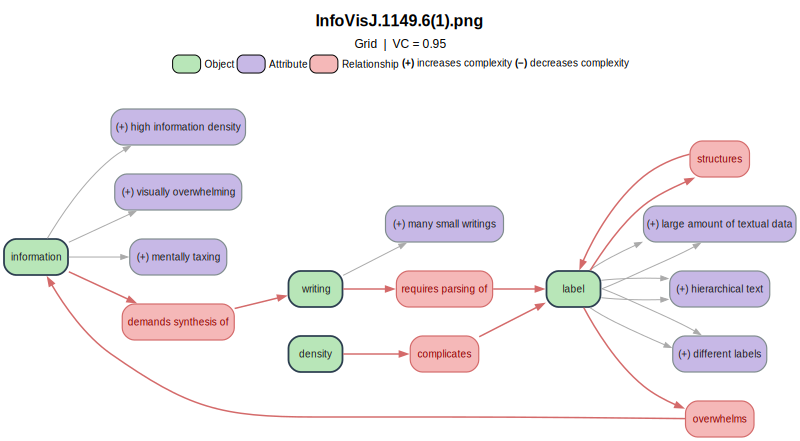

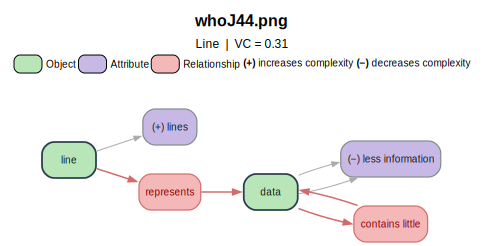

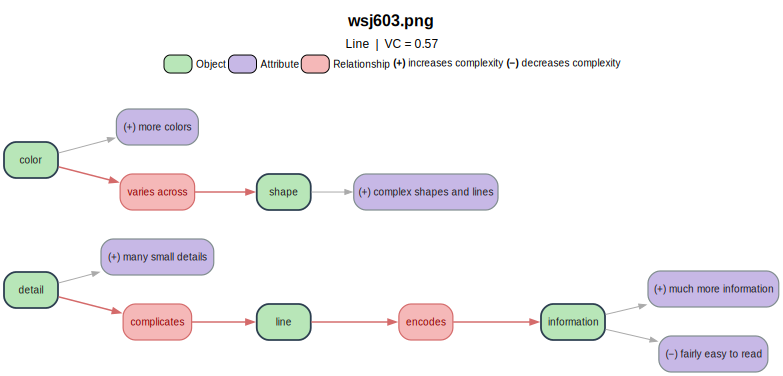

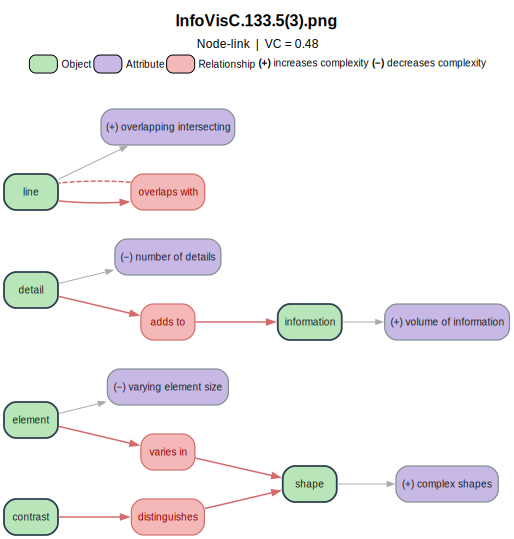

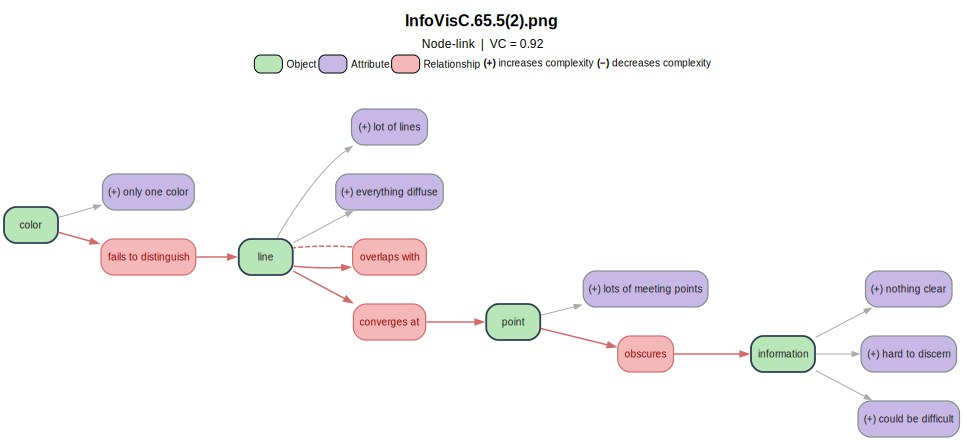

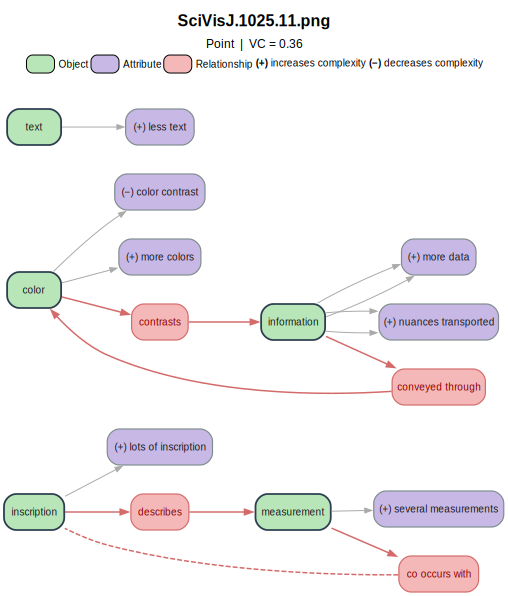

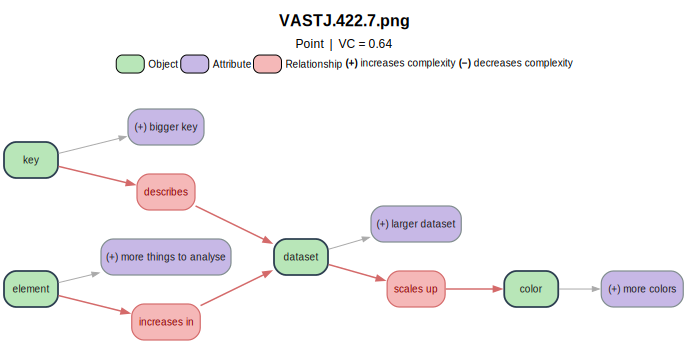

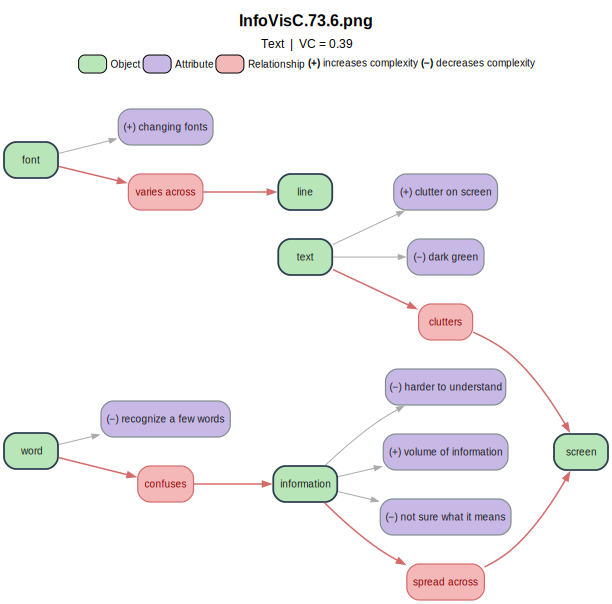

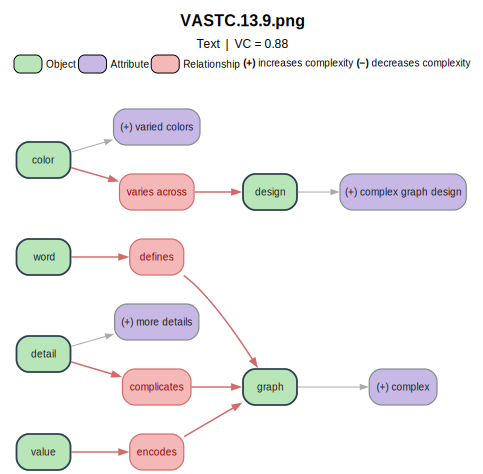


Saved 18 SVG graphs to vc_genome_output\graphs/


In [16]:
COLOR_OBJECT = '#b8e6b8'
COLOR_ATTRIBUTE = '#c7b8e6'
COLOR_RELATION = '#f5b8b8'
UNDIRECTED_PREDS = {'co_occurs_with', 'overlaps_with'}


def build_vg_graphviz(canon_data, image_name, vc, vistype):
    dot = graphviz.Digraph(
        name=image_name, format='svg',
        graph_attr={'rankdir': 'LR', 'fontsize': '10', 'fontname': 'Arial',
                    'nodesep': '0.4', 'ranksep': '0.6', 'splines': 'true', 'bgcolor': 'white'},
        node_attr={'fontname': 'Arial', 'fontsize': '10', 'shape': 'box',
                   'style': 'rounded,filled', 'penwidth': '1.2'},
        edge_attr={'fontname': 'Arial', 'fontsize': '9', 'color': '#888888'},
    )
    objects = canon_data['objects']
    attrs_by_obj = defaultdict(list)
    for i, attr in enumerate(canon_data['attributes']):
        sent = '(+)' if attr['sentiment'] == '+' else '(\u2212)'
        label = f"{sent} {attr['attr'].replace('_', ' ')[:30]}"
        attrs_by_obj[attr['object_synset']].append((f'attr_{i}', label))

    for obj in objects:
        dot.node(obj['synset'], label=obj['name'].replace('_', ' '),
                 fillcolor=COLOR_OBJECT, color='#2c3e50', fontcolor='#1a1a1a', penwidth='1.8')
    for obj in objects:
        for attr_id, attr_label in attrs_by_obj.get(obj['synset'], []):
            dot.node(attr_id, label=attr_label, fillcolor=COLOR_ATTRIBUTE,
                     color='#7f8c8d', fontcolor='#1a1a1a')
            dot.edge(obj['synset'], attr_id, color='#aaaaaa', arrowsize='0.7')

    for ri, rel in enumerate(canon_data['relationships']):
        pred_id = f'rel_{ri}'
        dot.node(pred_id, label=rel['predicate'].replace('_', ' '),
                 fillcolor=COLOR_RELATION, color='#d46a6a', fontcolor='#8b0000')
        dot.edge(rel['subject_synset'], pred_id, color='#d46a6a', penwidth='1.5', arrowsize='0.8')
        if rel['predicate'] in UNDIRECTED_PREDS:
            dot.edge(pred_id, rel['object_synset'], color='#d46a6a',
                     penwidth='1.5', style='dashed', arrowhead='none')
        else:
            dot.edge(pred_id, rel['object_synset'], color='#d46a6a', penwidth='1.5', arrowsize='0.8')

    title_legend_html = f'''<
    <TABLE BORDER="0" CELLBORDER="0" CELLSPACING="2" CELLPADDING="2">
    <TR><TD COLSPAN="8" ALIGN="CENTER"><B><FONT POINT-SIZE="16">{image_name}</FONT></B></TD></TR>
    <TR><TD COLSPAN="8" ALIGN="CENTER"><FONT POINT-SIZE="12">{vistype}  |  VC = {vc:.2f}</FONT></TD></TR>
    <TR>
      <TD BGCOLOR="#b8e6b8" BORDER="1" STYLE="rounded" WIDTH="28"> </TD><TD>Object</TD>
      <TD BGCOLOR="#c7b8e6" BORDER="1" STYLE="rounded" WIDTH="28"> </TD><TD>Attribute</TD>
      <TD BGCOLOR="#f5b8b8" BORDER="1" STYLE="rounded" WIDTH="28"> </TD><TD>Relationship</TD>
      <TD><B>(+)</B> increases complexity</TD>
      <TD><B>(\u2212)</B> decreases complexity</TD>
    </TR>
    <TR><TD COLSPAN="8" CELLPADDING="8"> </TD></TR>
    </TABLE>>'''
    dot.attr(label=title_legend_html, labelloc='t', labeljust='c')
    return dot


# Render all graphs
for _, row in examples.iterrows():
    img = row['imageName']
    canon = stage2_canonical[img]
    dot = build_vg_graphviz(canon, img, row['NormalizedVC'], row['VisType'])

    _stderr = sys.stderr
    sys.stderr = open(os.devnull, 'w')
    try:
        svg_data = dot.pipe(format='svg')
    finally:
        sys.stderr.close()
        sys.stderr = _stderr

    # Save to file
    safe_name = img.replace('(', '').replace(')', '').replace('.png', '')
    svg_path = GRAPH_DIR / f'{safe_name}.svg'
    svg_path.write_bytes(svg_data)

    # Display inline
    display(SVG(svg_data))

print(f'\nSaved {len(examples)} SVG graphs to {GRAPH_DIR}/')

### Subtopic Coverage Heatmap

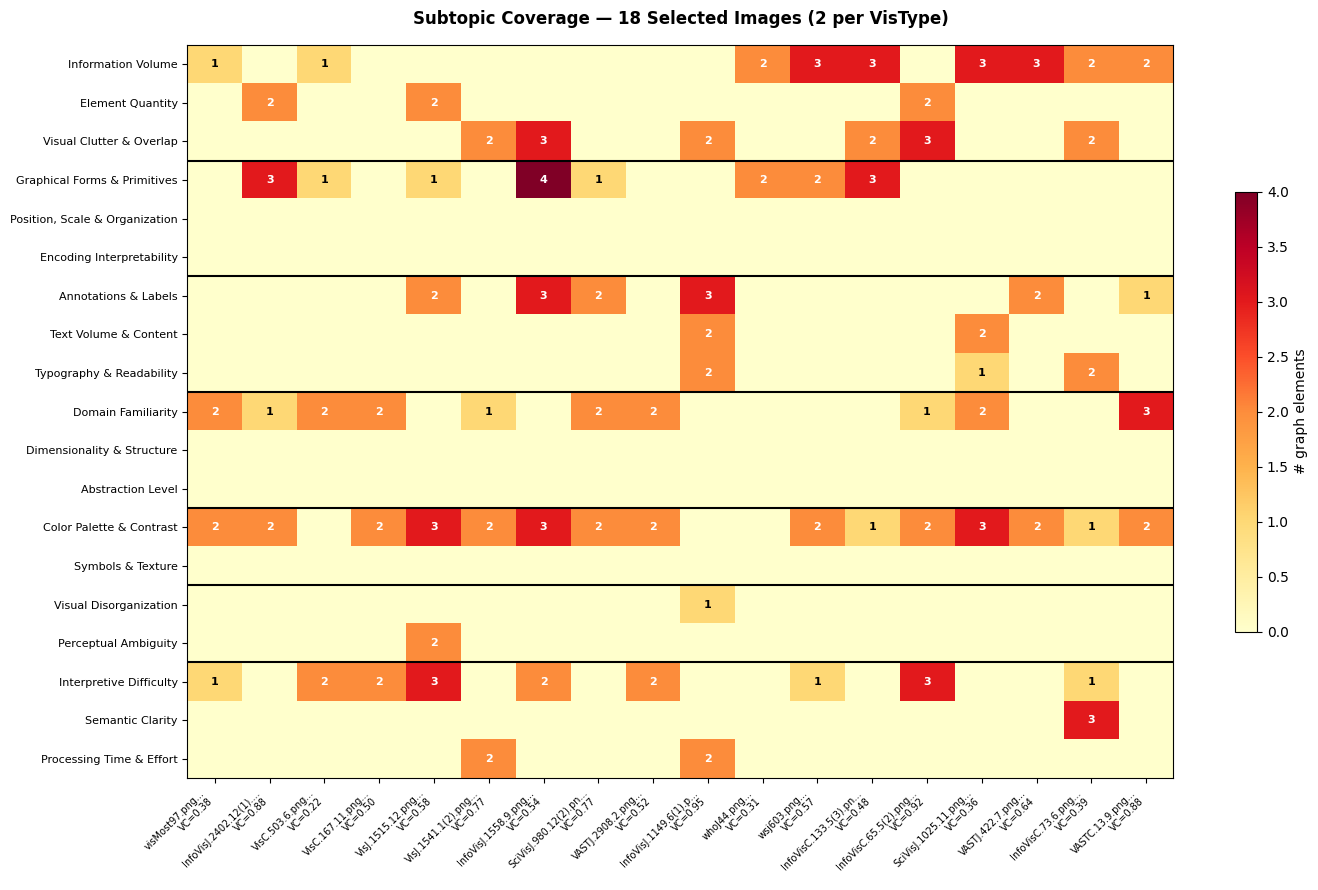

Saved heatmap to vc_genome_output/subtopic_coverage_heatmap.png


In [17]:
all_subtopics = subtopics_df['SubTopic'].tolist()
image_list = examples['imageName'].tolist()

coverage_data = {}
for img in image_list:
    canon = stage2_canonical[img]
    hit = Counter()
    for a in canon['attributes']:
        hit[a['subtopic']] += 1
    for r in canon['relationships']:
        hit[r['subtopic']] += 1
    coverage_data[img] = hit

# Build matrix
coverage_matrix = [[coverage_data[img].get(st, 0) for img in image_list] for st in all_subtopics]

# Save coverage as CSV
cov_df = pd.DataFrame(coverage_matrix, index=all_subtopics, columns=image_list)
cov_df.to_csv(OUT_DIR / 'subtopic_coverage.csv')

fig, ax = plt.subplots(figsize=(max(12, len(image_list) * 0.8), 9))
im = ax.imshow(coverage_matrix, cmap='YlOrRd', aspect='auto', interpolation='nearest')

vc_labels = [f"{img[:20]}...\nVC={examples.loc[examples['imageName']==img, 'NormalizedVC'].values[0]:.2f}"
             for img in image_list]
ax.set_xticks(range(len(image_list)))
ax.set_xticklabels(vc_labels, fontsize=7, rotation=45, ha='right')
ax.set_yticks(range(len(all_subtopics)))
ax.set_yticklabels(all_subtopics, fontsize=8)

prev_topic = None
for i, st in enumerate(all_subtopics):
    topic = subtopics_df.loc[subtopics_df['SubTopic']==st, 'Topic'].values[0]
    if prev_topic and topic != prev_topic:
        ax.axhline(y=i - 0.5, color='black', linewidth=1.5)
    prev_topic = topic

for i in range(len(all_subtopics)):
    for j in range(len(image_list)):
        val = coverage_matrix[i][j]
        if val > 0:
            ax.text(j, i, str(val), ha='center', va='center',
                    fontsize=8, fontweight='bold',
                    color='white' if val >= 2 else 'black')

ax.set_title('Subtopic Coverage — 18 Selected Images (2 per VisType)',
             fontsize=12, fontweight='bold', pad=15)
plt.colorbar(im, ax=ax, label='# graph elements', shrink=0.6)
plt.tight_layout()
fig.savefig(OUT_DIR / 'subtopic_coverage_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved heatmap to {OUT_DIR}/subtopic_coverage_heatmap.png')

### Output Summary

In [19]:
print('=== VC-Genome Pipeline Output ===')
print(f'Images processed: {len(examples)}')
print(f'VisTypes covered: {examples["VisType"].nunique()}')
print(f'\nFiles in {OUT_DIR}/:')
for f in sorted(OUT_DIR.glob('*')):
    if f.is_file():
        print(f'  {f.name:40s} {f.stat().st_size:>8,d} bytes')
print(f'\nGraphs in {GRAPH_DIR}/:')
for f in sorted(GRAPH_DIR.glob('*.svg')):
    print(f'  {f.name:40s} {f.stat().st_size:>8,d} bytes')

=== VC-Genome Pipeline Output ===
Images processed: 18
VisTypes covered: 9

Files in vc_genome_output/:
  graph_metrics.csv                           1,227 bytes
  llm_extractions.json                       34,673 bytes
  subtopic_coverage.csv                       1,460 bytes
  subtopic_coverage_heatmap.png             159,356 bytes

Graphs in vc_genome_output\graphs/:
  InfoVisC.133.53.svg                        16,790 bytes
  InfoVisC.65.52.svg                         17,688 bytes
  InfoVisC.73.6.svg                          19,077 bytes
  InfoVisJ.1149.61.svg                       20,596 bytes
  InfoVisJ.1558.9.svg                        23,049 bytes
  InfoVisJ.2402.121.svg                      15,243 bytes
  SciVisJ.1025.11.svg                        19,002 bytes
  SciVisJ.980.122.svg                        13,956 bytes
  VASTC.13.9.svg                             15,808 bytes
  VASTJ.2908.2.svg                           12,847 bytes
  VASTJ.422.7.svg                            13